In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
from schema4one.backend.model_np import FeedForwardCells, RecurrentCells, PlaceCells
from schema4one.backend.utils import get_default_hp
from sklearn.decomposition import PCA

In [2]:
# initialize network
hp = get_default_hp('6pa')

seed = 0
np.random.seed(seed)

ncues = 6
gain = 3
cues = np.eye(ncues) * gain

hp['tstep'] = 20
hp['npc'] = 7

x_vals = np.linspace(-0.8,0.8,21)
traj = np.meshgrid(x_vals, x_vals)
traj = np.stack(traj, axis=-1).reshape(-1, 2)
pc = PlaceCells(hp)
pc_act = np.array([pc.sense(xy) for xy in traj])
time = len(pc_act)

# pc_act = np.zeros_like(pc_act)



In [ ]:
nonlinearities = ['relu', 'tanh', 'phia']
network_types = ['FF', 'Res']
hp['nrnn'] = 1024

ff_act = np.zeros((len(nonlinearities), ncues, time, hp['nrnn']))
res_act = np.zeros((len(nonlinearities), ncues, time, hp['nrnn']))


for nl, nonlinearity in enumerate(nonlinearities):
    hp['ract'] = nonlinearity
    ff = FeedForwardCells(hp, ninput=hp['npc']**2 + ncues)
    res = RecurrentCells(hp, ninput=hp['npc']**2 + ncues)

    for c, cue in enumerate(cues):
        res.reset()
        for t in range(time):
            input_vec = np.concatenate([cue, pc_act[t]])
            ff_act[nl, c, t] = ff.process(input_vec[None, :])
            res_act[nl, c, t] = res.process(input_vec[None, :])

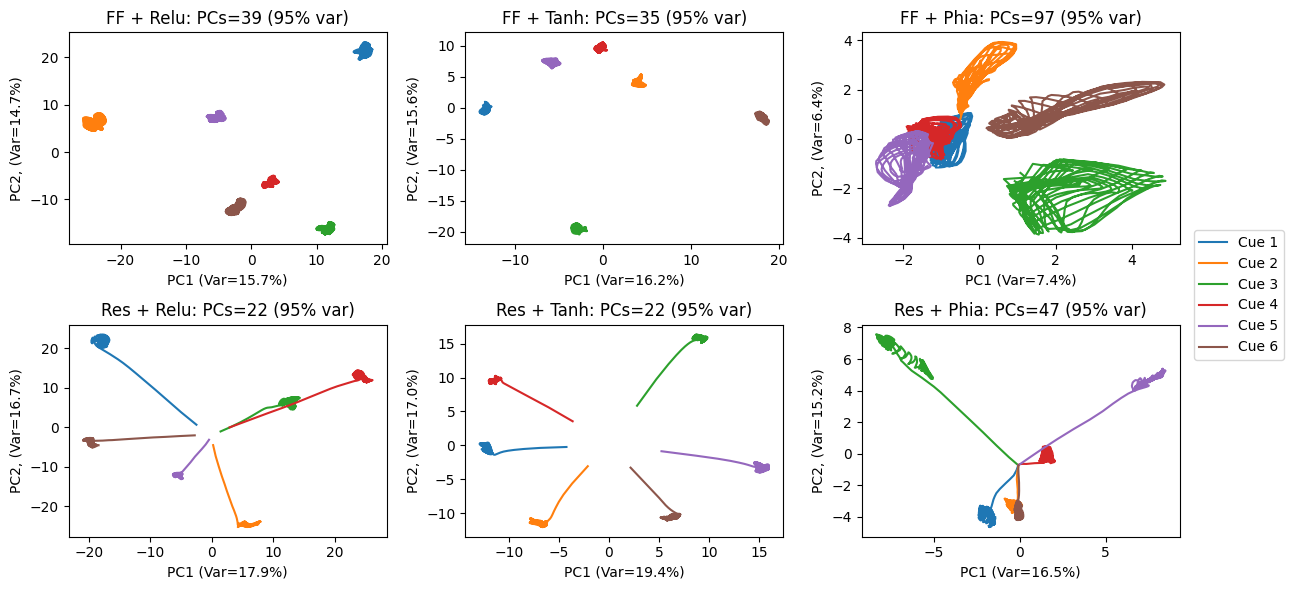

In [6]:
# plot PCA

f,ax = plt.subplots(2, len(nonlinearities), figsize=(4*len(nonlinearities), 3*2))


for nl, nonlinearity in enumerate(nonlinearities):

    for i, network_type in enumerate([ff_act, res_act]):
        network = network_type[nl]

        pca = PCA(n_components=0.95)
        network_reshape = network.reshape(-1, hp['nrnn'])
        ff_act_pca = pca.fit_transform(network_reshape)
        ff_act_2d = ff_act_pca[:, :2]
        ff_act_2d = ff_act_2d.reshape(ncues, time, 2)


        for c in range(ncues):
            ax[i, nl].plot(ff_act_2d[c, :, 0], ff_act_2d[c, :, 1], label=f'Cue {c+1}')
        ax[i, nl].set_xlabel('PC1 (Var={:.1f}%)'.format(pca.explained_variance_ratio_[0]*100))
        ax[i, nl].set_ylabel('PC2, (Var={:.1f}%)'.format(pca.explained_variance_ratio_[1]*100))
        ax[i, nl].set_title(f'{network_types[i]} + {nonlinearity.capitalize()}: PCs={pca.n_components_} (95% var)')
        # ax[i, nl].legend()

# add legend to the right of the last column
handles, labels = ax[0, -1].get_legend_handles_labels()
f.legend(handles, labels, loc='center right', bbox_to_anchor=(1.08, 0.5))


f.tight_layout()

f.savefig('./figs/cue_ff_subspace.pdf',  bbox_inches='tight')

Text(0.5, 1.0, 'Eigenspectrum of FF + phia')

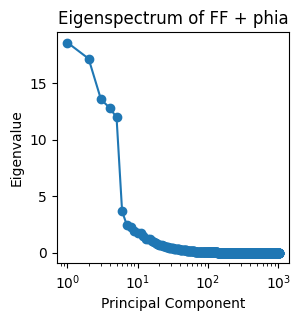

In [5]:
# get full eigenvalues and vectors
np.eigvals, np.eigvecs = np.linalg.eig(np.cov(network_reshape.T))

plt.figure(figsize=(3, 3))
plt.plot(np.arange(1, hp['nrnn']+1), np.eigvals, marker='o')
plt.xscale('log')
# plt.yscale('log')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.title(f'Eigenspectrum of FF + {hp['ract']}')